<a href="https://colab.research.google.com/github/FishyFoshy/COMP3608-Project/blob/main/Dataset_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import subprocess
import sys

packages = [
    'numpy',
    'pandas',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'xgboost',
    'scipy',
    'notebook',
    'jupyter'
]

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

print("All packages installed!")

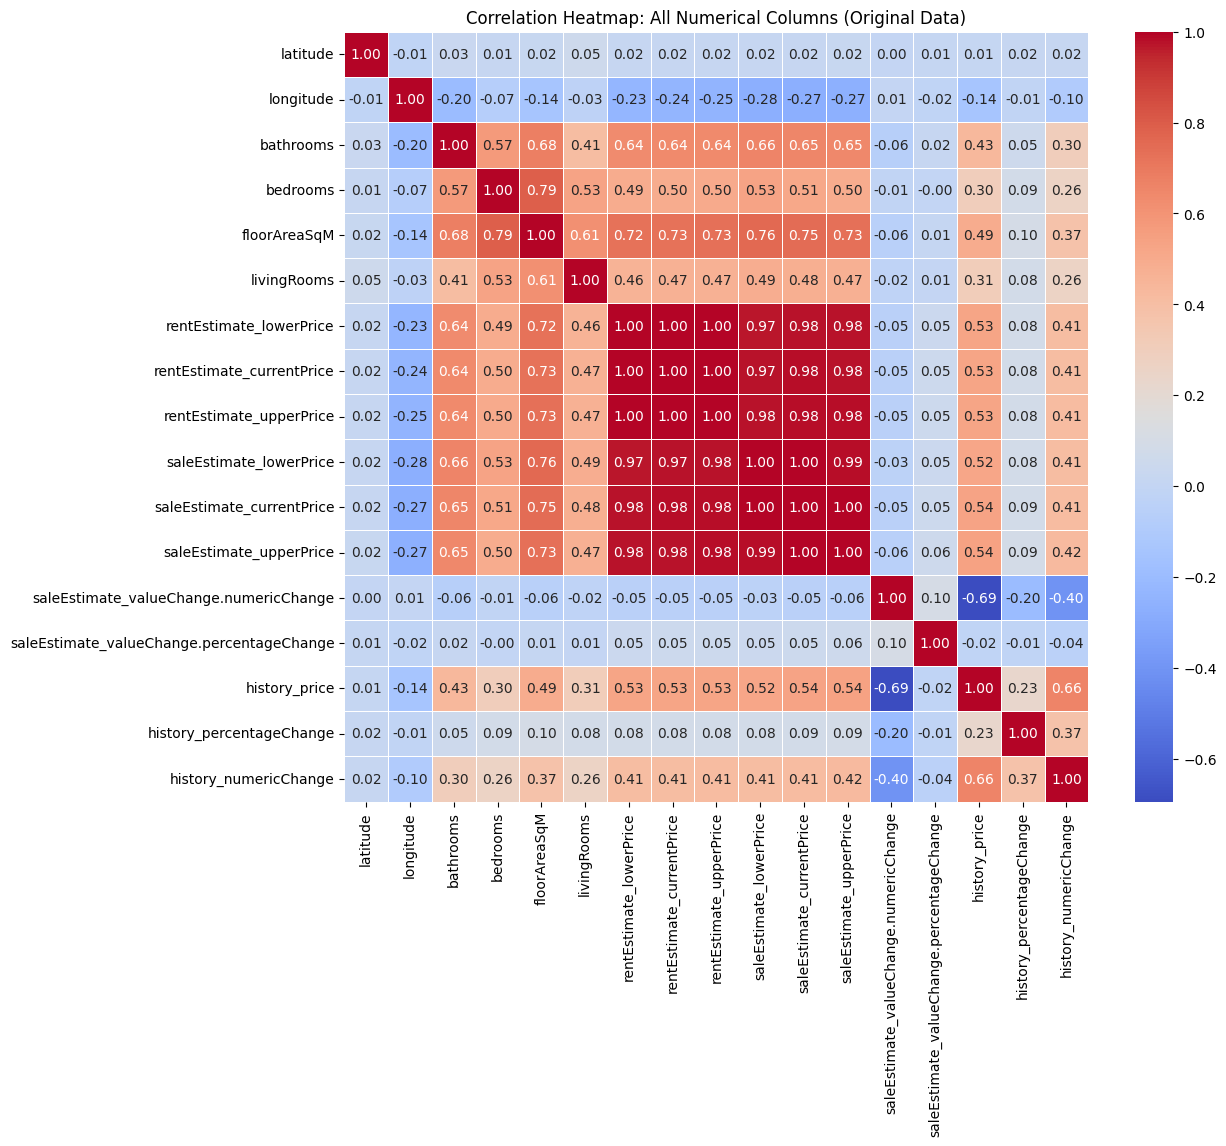

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the original dataset for correlation analysis before any cleaning
df_original_for_heatmap = pd.read_csv('kaggle_london_house_price_data.csv')

# Select only numerical columns for correlation calculation
numerical_cols = df_original_for_heatmap.select_dtypes(include=np.number).columns
corr = df_original_for_heatmap[numerical_cols].corr().round(3)

plt.figure(figsize=(12, 10)) # Adjust figure size for more columns
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap: All Numerical Columns (Original Data)')
plt.show()

### Pre-Cleaning Correlation Analysis

The heatmap above shows the correlations between all numeric features in the raw Dataset 1. This motivates the column drops performed in the cleaning step:

- `saleEstimate_lowerPrice` / `saleEstimate_upperPrice` gives a near-perfect correlation with the target `saleEstimate_currentPrice`. Therefore, keeping them would encourage data leakage.
- `rentEstimate_*` columns are highly intercorrelated and capture rental market dynamics rather than sale price drivers.
- `history_price` / `history_numericChange` / `history_percentageChange` are redundant with current sale estimate; historical data is already encoded in the target.
- `saleEstimate_valueChange.*` is derived directly from price change calculations, creating redundancy.

### Cleaning of Dataset 1

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Load datasets
df1 = pd.read_csv('kaggle_london_house_price_data.csv')

# Removes rows that don't have HIGH confidence in their sales estimates
df1 = df1[(df1['saleEstimate_confidenceLevel'] == 'HIGH')]

# Drops all unnecessary columns
df1 = df1.drop(columns=['fullAddress', 'postcode', 'rentEstimate_lowerPrice', 'rentEstimate_currentPrice', 'rentEstimate_upperPrice', 
                        'saleEstimate_lowerPrice', 'saleEstimate_upperPrice', 'saleEstimate_ingestedAt', 'saleEstimate_valueChange.numericChange', 
                        'saleEstimate_valueChange.percentageChange', 'saleEstimate_valueChange.saleDate', 'history_date', 'history_price', 'history_percentageChange', 
                        'history_numericChange', 'saleEstimate_confidenceLevel'])

# Drops all with null values
df1.dropna(inplace=True)

# Remove the top 1% highest prices to reduce high-end outliers before log-transform
upper_quantile = df1['saleEstimate_currentPrice'].quantile(0.99)
df1 = df1[df1['saleEstimate_currentPrice'] <= upper_quantile]

# Apply log transform to the target
df1['saleEstimate_currentPrice'] = np.log(df1['saleEstimate_currentPrice'])

# Create a copy of df1 for Linear Regression before feature engineering
df1lr = df1.copy()

# Apply location-based feature engineering to df1lr only (for Linear Regression)
df1lr['lat_lon_interaction'] = df1lr['latitude'] * df1lr['longitude']
center_lat = df1lr['latitude'].mean()
center_lon = df1lr['longitude'].mean()
df1lr['dist_to_center'] = np.sqrt((df1lr['latitude'] - center_lat)**2 + (df1lr['longitude'] - center_lon)**2)
df1lr = df1lr.drop(columns=['latitude', 'longitude'])  # Drop original lat/lon to avoid multicollinearity

# Separates non numerical columns from numerical ones
non_numerical_columns = ['saleEstimate_currentPrice', 'tenure', 'propertyType', 'currentEnergyRating']

# Process df1lr (for Linear Regression): scale and encode
numerical_features_lr = [col for col in df1lr.columns if col not in non_numerical_columns]
scaler_lr = StandardScaler()
df1lr[numerical_features_lr] = scaler_lr.fit_transform(df1lr[numerical_features_lr])
categorical_cols_lr = df1lr.select_dtypes(include='object').columns
df1lr = pd.get_dummies(df1lr, columns=categorical_cols_lr, drop_first=True)

target_column = 'saleEstimate_currentPrice'
x_lr = df1lr[[col for col in df1lr.columns if col != target_column]].copy()
y_lr = df1lr[target_column].copy()
x_train_lr, x_test_lr, y_train_lr, y_test_lr = train_test_split(x_lr, y_lr, test_size=0.2, random_state=42)

# Process df1 (for tree models: Random Forest, XGBoost): keep raw lat/lon, scale and encode
numerical_features = [col for col in df1.columns if col not in non_numerical_columns]
scaler = StandardScaler()
df1[numerical_features] = scaler.fit_transform(df1[numerical_features])
categorical_cols_to_encode = df1.select_dtypes(include='object').columns
df1 = pd.get_dummies(df1, columns=categorical_cols_to_encode, drop_first=True)

features = [col for col in df1.columns if col != target_column]
x = df1[features].copy()
y = df1[target_column].copy()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("=" * 60)
print("DATASET 1: kaggle_london_house_price_data.csv")
print("=" * 60)
print("\nFirst 10 rows:")
display(df1.head(10))
print("\nData types:")
print(df1.dtypes)
print("\nMissing values:")
print(df1.isnull().sum())
print("\nTarget variable (saleEstimate_currentPrice) statistics:")
print(df1['saleEstimate_currentPrice'].describe())

DATASET 1: kaggle_london_house_price_data.csv

First 10 rows:


,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,saleEstimate_currentPrice,tenure_Freehold,tenure_Leasehold,tenure_Shared,propertyType_Converted Flat,propertyType_Detached Bungalow,propertyType_Detached House,propertyType_Detached Property,propertyType_End Terrace Bungalow,propertyType_End Terrace House,propertyType_End Terrace Property,propertyType_Flat/Maisonette,propertyType_Mid Terrace Bungalow,propertyType_Mid Terrace House,propertyType_Mid Terrace Property,propertyType_Purpose Built Flat,propertyType_Semi-Detached Bungalow,propertyType_Semi-Detached House,propertyType_Semi-Detached Property,propertyType_Terrace Property,propertyType_Terraced,propertyType_Terraced Bungalow,currentEnergyRating_B,currentEnergyRating_C,currentEnergyRating_D,currentEnergyRating_E,currentEnergyRating_F,currentEnergyRating_G
3,-0.436078,0.006681,-0.635925,-1.406002,-0.735789,-0.538528,12.868761,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,1.372526,-0.502899,-0.635925,1.302532,0.812574,1.312408,14.047416,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
5,-0.633914,1.072851,-0.635925,-0.503157,-0.035844,-0.538528,13.757881,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False
6,-0.875323,0.916570,-0.635925,0.399687,0.770153,1.312408,13.495305,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
8,1.279829,0.974468,-0.635925,1.302532,0.388365,1.312408,13.732129,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False
9,1.372526,-0.502899,-0.635925,1.302532,0.812574,1.312408,14.052162,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
10,1.949118,0.780674,0.942927,1.302532,0.918626,1.312408,13.304685,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
11,1.949118,0.780674,0.942927,1.302532,0.918626,1.312408,13.286181,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
14,-0.214742,-1.035905,0.942927,-0.503157,-0.057055,1.312408,14.349662,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
17,-0.588411,0.671537,0.942927,0.399687,0.176260,-0.538528,13.577253,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False



Data types:
latitude                               float64
longitude                              float64
bathrooms                              float64
bedrooms                               float64
floorAreaSqM                           float64
livingRooms                            float64
saleEstimate_currentPrice              float64
tenure_Freehold                           bool
tenure_Leasehold                          bool
tenure_Shared                             bool
propertyType_Converted Flat               bool
propertyType_Detached Bungalow            bool
propertyType_Detached House               bool
propertyType_Detached Property            bool
propertyType_End Terrace Bungalow         bool
propertyType_End Terrace House            bool
propertyType_End Terrace Property         bool
propertyType_Flat/Maisonette              bool
propertyType_Mid Terrace Bungalow         bool
propertyType_Mid Terrace House            bool
propertyType_Mid Terrace Property         bool


In [4]:
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
import numpy as np
# Inverse the log transformation to its original scale

def rmse_original_scale(y_true, y_pred):
    y_true_original = np.exp(y_true)
    y_pred_original = np.exp(y_pred)
    # Calculate RMSE on the original scale
    return np.sqrt(mean_squared_error(y_true_original, y_pred_original))

def mae_original_scale(y_true, y_pred):
    y_true_original = np.exp(y_true)
    y_pred_original = np.exp(y_pred)
    # Calculate MAE on the original scale
    return mean_absolute_error(y_true_original, y_pred_original)

def r2_original_scale(y_true, y_pred):
    y_true_original = np.exp(y_true)
    y_pred_original = np.exp(y_pred)
    # Calculate R2 on the original scale
    return r2_score(y_true_original, y_pred_original)

# Create scorers that can be used with cross_val_score
neg_rmse_original_scorer = make_scorer(rmse_original_scale, greater_is_better=False)
neg_mae_original_scorer = make_scorer(mae_original_scale, greater_is_better=False)
r2_original_scorer = make_scorer(r2_original_scale, greater_is_better=True)

### Linear Regression for Dataset 1

BASELINE: Linear Regression on Dataset 1.csv
RMSE:	$295,220.78
MAE:	$163,665.16
R²:	0.6694

Cross-validation RMSE:	$301,509.51
Cross-validation MAE:	$164,072.88
Cross-validation R²:	0.6586


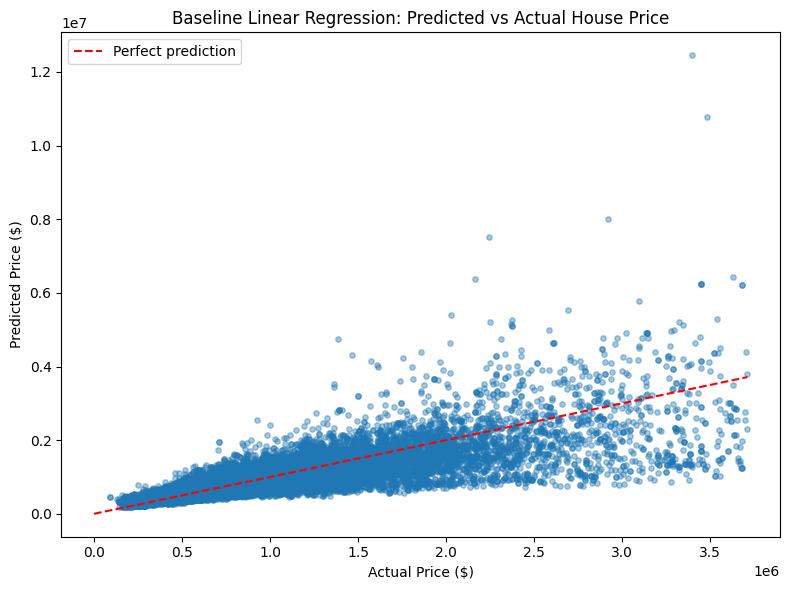

In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Train baseline Linear Regression
lr = LinearRegression()
lr.fit(x_train_lr, y_train_lr)
y_pred_lr = lr.predict(x_test_lr)

# Inverse log transform to get actual prices
y_test_lr_actual = np.exp(y_test_lr)
y_pred_lr_actual = np.exp(y_pred_lr)

# Evaluate on original scale
rmse_lr = np.sqrt(mean_squared_error(y_test_lr_actual, y_pred_lr_actual))
mae_lr = mean_absolute_error(y_test_lr_actual, y_pred_lr_actual)
r2_lr = r2_score(y_test_lr_actual, y_pred_lr_actual)

print("=" * 50)
print("BASELINE: Linear Regression on Dataset 1.csv")
print("=" * 50)
print(f"RMSE:\t${rmse_lr:,.2f}")
print(f"MAE:\t${mae_lr:,.2f}")
print(f"R²:\t{r2_lr:.4f}")
print(f"\nCross-validation RMSE:\t${-cross_val_score(lr, x_lr, y_lr, cv=5, scoring=neg_rmse_original_scorer).mean():,.2f}")
print(f"Cross-validation MAE:\t${-cross_val_score(lr, x_lr, y_lr, cv=5, scoring=neg_mae_original_scorer).mean():,.2f}")
print(f"Cross-validation R²:\t{cross_val_score(lr, x_lr, y_lr, cv=5, scoring=r2_original_scorer).mean():.4f}")

# Predicted vs Actual scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_test_lr_actual, y_pred_lr_actual, alpha=0.4, s=15)
plt.plot([0, y_test_lr_actual.max()], [0, y_test_lr_actual.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Baseline Linear Regression: Predicted vs Actual House Price')
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance Plot

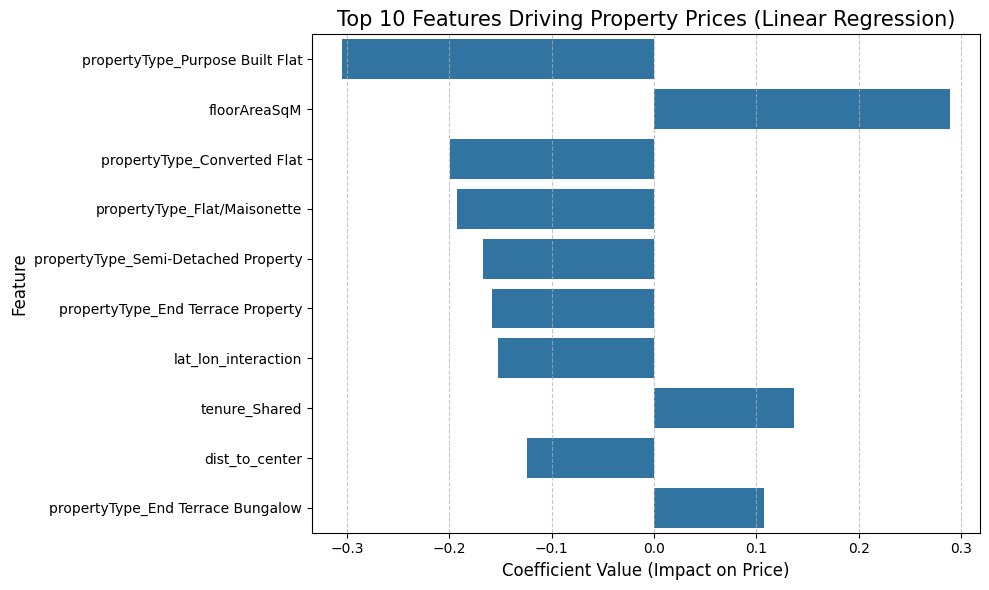

,Feature,Coefficient
20,propertyType_Purpose Built Flat,-0.304336
2,floorAreaSqM,0.288662
9,propertyType_Converted Flat,-0.199461
16,propertyType_Flat/Maisonette,-0.192301
23,propertyType_Semi-Detached Property,-0.167082
15,propertyType_End Terrace Property,-0.157996
4,lat_lon_interaction,-0.152389
8,tenure_Shared,0.136731
5,dist_to_center,-0.123935
13,propertyType_End Terrace Bungalow,0.106950


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Fetching Feature Names and Coefficients
feature_names = x_train_lr.columns
coefficients = lr.coef_

# Wrapping them together in a Pandas DataFrame for Easy Comparison and Viewing
feature_importance_lr = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Using the Absolute Function before Sorting the Coefficients in Descending Order
feature_importance_lr['Abs_Coefficient'] = np.abs(feature_importance_lr['Coefficient'])
top_10_features_lr = feature_importance_lr.sort_values(by='Abs_Coefficient', ascending=False).head(10)

# Plotting Graph
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_features_lr,
    x='Coefficient',
    y='Feature',
)
plt.title('Top 10 Features Driving Property Prices (Linear Regression)', fontsize=15)
plt.xlabel('Coefficient Value (Impact on Price)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
display(top_10_features_lr[['Feature', 'Coefficient']])

### Analysis

The R² of the Linear Regression model is 0.6694, which implies that the model explains about 67% of the price movement in the property prices. An average error of £163,665 provides a decent description of the average error of prediction and the root mean squared error is much larger at £295,221. The difference between MAE and RMSE indicates that there is a set of large errors, further confirmed by the scatter plot, which demonstrates that most of the lower-priced properties (less than about £1.5M) are following fairly well along the diagonal, but there exists a cluster of extreme overestimates at the higher end, with predictions of properties exceeding £10M occurring for property values actually worth £2.5-3.5M. This extreme volatility is a structural weakness of linear regression in the case of a skewed price distribution towards the right. The results of cross-validation are in line with the results: CV RMSE of £301,510, CV MAE of £164,073, and CV R-Squared of 0.6586 indicating that the model is not over-fitting.

The most influential feature is floorAreaSqM with the largest positive coefficient of 0.289 in the log-transformed space. A one standard deviation increase in floor area is linked to a more or less 29% increase in the predicted price, which is logical, since larger properties are associated with having significantly higher sale prices.

Property type dummies dominate the negative side of the chart. The propertyTypePurpose Built Flat has the lowest coefficient (−0.304), then the propertytype Converted Flat ( -0.199), propertytype Flat/Maisonette ( -0.192), propertytype Semi-Detached Property ( -0.167), and propertytype End Terrace Property (-0.158). All these are sold at a huge discount as compared to the excluded baseline category (detached houses), which are in line with known UK market trends.

Two engineered geographic features appear in the top 10. lat_lon_interaction (latitude × longitude) was created so that the model would have only one term in which it could compute the combined geographic location of a property, as opposed to considering latitude and longitude as merely additive features. Its negative coefficient (-0.152) is a general measure of the pricing gradient across the spatial range of the dataset. dist_to_center (Euclidean distance to the geographic center of the dataset) was also designed to allow let the model interact with distance from the densest, usually highest-priced portion of the sample; the negative coefficient (-0.124) of dist_to_center confirms that properties further from the center are associated with lower predicted prices.

tenureShared has a significant positive coefficient (+0.137), probably due to the composition bias in the data, being that shared-ownership properties in this dataset may skew towards more expensive urban areas, rather than indicating a genuine tenure premium (i.e. how much more or less buys will pay for one tenure type). The other type of property with a small positive coefficient is propertytypeEnd Terrace Bungalow which has a slight premium over some of the flat categories which make up the negative tail.

The main weakness of this model lies in its weak calibration at the upper end of the price distribution: the RMSE is almost twice the MAE, which is a clear indication of large outlier errors. Its R², of 0.6694 and cross-validated R² of 0.6586 represents a significant proportion of variance, but the remaining 33% is due to non-linear interactions that the model cannot capture. These interactions and the high-end prediction error should be better handled by non-linear models like the Random Forest.

#### Hyperparameter Tuning (GridSearchCV)

Because this GridSearch was very computationally heavy, I isolated one of the parameters and tested those parameter values until the performance completely plateaued, then I kept the best parameter value and tested it alongside another isolated parameter. That is the reason for the parameters selected for the Random Forest Regression afterwards and is also the reason you see the commented out original feature selections.

In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [153], # Originally a range from 150 to 200
    'max_features': [None], # Originally ['sqrt', 'log2', 0.3, 0.2, None]
    'min_samples_leaf': [1], # Originally [1, 2, 4]
    'max_depth': [39] # Originally [10, 20, 30, None]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring=neg_mae_original_scorer,
    n_jobs=5,
    verbose=2
)

grid_search.fit(x_train, y_train)
best_params = grid_search.best_params_
best_score = np.sqrt(abs(grid_search.best_score_)) # Convert neg_root_mean_squared_error back to RMSE

print(f"\nBest Parameters: {best_params}")
print(f"Best Cross-Validation RMSE: ${best_score:,.2f}")

best_rfr_model = grid_search.best_estimator_

y_pred_tuned = best_rfr_model.predict(x_test)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("\n--- Tuned Random Forest Model Performance ---")
print(f"RMSE on Test Set:\t${rmse_tuned:,.2f}")
print(f"MAE on Test Set:\t${mae_tuned:,.2f}")
print(f"R² on Test Set:\t{r2_tuned:.4f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best Parameters: {'max_depth': 39, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 153}
Best Cross-Validation RMSE: $164.65

--- Tuned Random Forest Model Performance ---
RMSE on Test Set:	$0.05
MAE on Test Set:	$0.03
R² on Test Set:	0.9901


### Random Forest Regression for Dataset 1

Random Forest Regressor on Dataset 1.csv
RMSE:	$58,734.52
MAE:	$21,498.67
R²:	0.9869

Cross-validation RMSE:	$55,780.03
Cross-validation MAE:	$21,317.15
Cross-validation R²:	0.9866


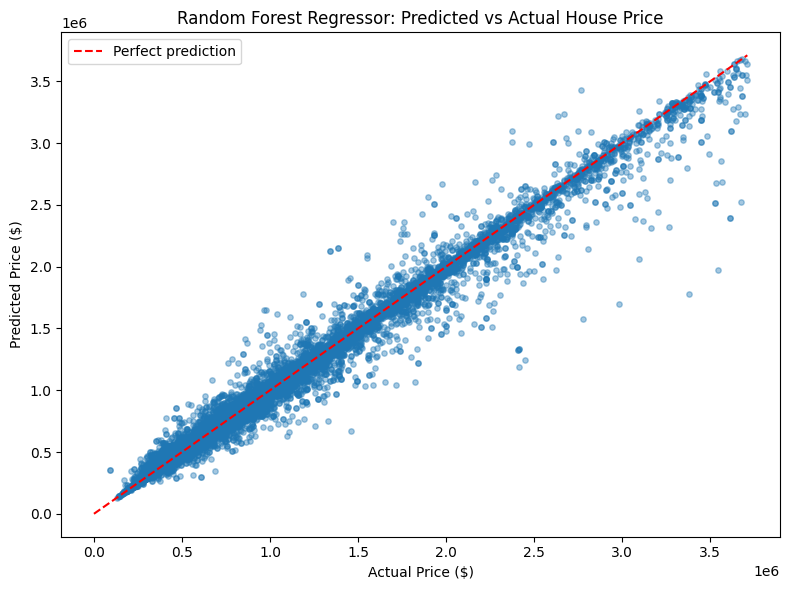

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

rf = RandomForestRegressor(n_estimators=153, n_jobs=5, max_features=None, max_depth=39, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

# Inverse log transform to get actual prices
y_test_actual = np.exp(y_test)
y_pred_rf_actual = np.exp(y_pred_rf)

# Evaluate on original scale
rmse_rf = np.sqrt(mean_squared_error(y_test_actual, y_pred_rf_actual))
mae_rf = mean_absolute_error(y_test_actual, y_pred_rf_actual)
r2_rf = r2_score(y_test_actual, y_pred_rf_actual)

print("=" * 50)
print("Random Forest Regressor on Dataset 1.csv")
print("=" * 50)
print(f"RMSE:\t${rmse_rf:,.2f}")
print(f"MAE:\t${mae_rf:,.2f}")
print(f"R²:\t{r2_rf:.4f}")

print(f"\nCross-validation RMSE:\t${-cross_val_score(rf, x, y, cv=5, scoring=neg_rmse_original_scorer).mean():,.2f}")
print(f"Cross-validation MAE:\t${-cross_val_score(rf, x, y, cv=5, scoring=neg_mae_original_scorer).mean():,.2f}")
print(f"Cross-validation R²:\t{cross_val_score(rf, x, y, cv=5, scoring=r2_original_scorer).mean():.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred_rf_actual, alpha=0.4, s=15)
plt.plot([0, y_test_actual.max()], [0, y_test_actual.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Random Forest Regressor: Predicted vs Actual House Price')
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance Plot

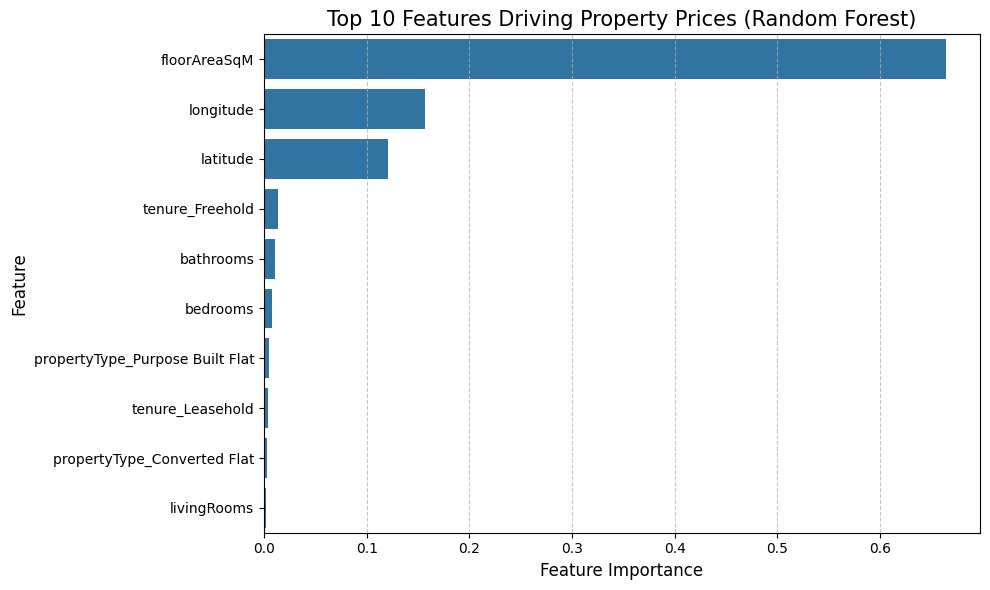

,Feature,Importance
4,floorAreaSqM,0.664262
1,longitude,0.157212
0,latitude,0.120809
6,tenure_Freehold,0.013886
2,bathrooms,0.010745
3,bedrooms,0.007353
20,propertyType_Purpose Built Flat,0.004507
7,tenure_Leasehold,0.003721
9,propertyType_Converted Flat,0.002623
5,livingRooms,0.001942


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fetching Feature Names and Importances from Random Forest
feature_names = x_train.columns
importances = rf.feature_importances_

# Wrapping them together in a Pandas DataFrame for Easy Comparison and Viewing
feature_importance_rf = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sorting Feature Importances in Descending Order
top_10_features_rf = feature_importance_rf.sort_values(by='Importance', ascending=False).head(10)

# Plotting Graph
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_features_rf,
    x='Importance',
    y='Feature',
)
plt.title('Top 10 Features Driving Property Prices (Random Forest)', fontsize=15)
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
display(top_10_features_rf[['Feature', 'Importance']])

### Analysis

The story of what drives property prices as explained by the Random Forest model is quite different than the Linear Regression. The continuous variables that dominate the majority of this feature importance chart are: floorAreaSqM (~0.67), longitude (~0.16) and latitude (~0.12). Combining the three features, the overall predictive power of the model is computed to be around 95 percent, whereas all other features have only small significant value.

The most significant feature, which is floorareaSqM, is not only consistent with the results of the Linear Regression but also makes sense in the real world, being that property size is the one of, if not the most important characteristic to predict price. But the most interesting thing about the Random Forest model is the prominence of longitude and latitude. These geographic coordinates were hardly visible in the most popular features of the Linear Regression as the impact of location on price is very non-linear. For instance, a property in central London (specific longitude/latitude ranges) can be worth 1.11x the price of a similar property elsewhere, as indicated in the code block below. The Random Forest can capture these non-linear spatial patterns through its tree-based splits, effectively learning "if longitude is between X and Y and latitude is between A and B, then the property is in a premium area."

The other attributes such as "bedrooms, bathrooms, tenure Freehold, living Rooms and other types of property have lower contribution of less than 1-2 percent each. This does not imply they are irrelevant, but that once the floor area and location is known, they contribute a marginal amount to the predictive signal. This is in part due to the fact that much of the information that will be given by bedrooms and bathrooms is already encoded in the floor area (larger homes naturally have more rooms).

The scatter plot proves the superiority of the Random Forest: the predictions follow the diagonal line far better through the whole price range, even the higher bracket where Linear Regression failed. The RMSE is much lower than the Linear Regression and the difference between the RMSE and MAE is much less, meaning that the model no longer suffers the extreme outlier errors that affected the linear model on the high end.

The general lesson learned is that in this case, is that property prices depend mostly on size and location, and the non-linear geographic pricing patterns that Linear Regression can not identify can be captured by the Random Forest. The fact that the model only uses three features to make 94% of its predictions also indicates that a finer location-based features (e.g. proximity to transport, school ratings, neighbourhood crime rates) may be useful in this dataset to give it additional predictive power over raw coordinates.

### Supporting Evidence: Central London vs. Non-Central London Price Disparity

In [10]:
import numpy as np
import pandas as pd

# Reload raw data to work with actual (untransformed) prices
df_raw = pd.read_csv('kaggle_london_house_price_data.csv')
df_raw = df_raw[df_raw['saleEstimate_confidenceLevel'] == 'HIGH']
upper_quantile = df_raw['saleEstimate_currentPrice'].quantile(0.99)
df_raw = df_raw[df_raw['saleEstimate_currentPrice'] <= upper_quantile]
df_raw.dropna(subset=['saleEstimate_currentPrice', 'latitude', 'longitude'], inplace=True)

# Covers: Westminster, City of London, Kensington & Chelsea, Camden core
CENTRAL_LON_MIN, CENTRAL_LON_MAX = -0.18, 0.05
CENTRAL_LAT_MIN, CENTRAL_LAT_MAX =  51.48, 51.54

df_raw['is_central'] = (
    (df_raw['longitude'] >= CENTRAL_LON_MIN) & (df_raw['longitude'] <= CENTRAL_LON_MAX) &
    (df_raw['latitude']  >= CENTRAL_LAT_MIN) & (df_raw['latitude']  <= CENTRAL_LAT_MAX)
)

central = df_raw[df_raw['is_central']]['saleEstimate_currentPrice']
non_central = df_raw[~df_raw['is_central']]['saleEstimate_currentPrice']

mean_central = central.mean()
mean_non_central = non_central.mean()
ratio = mean_central / mean_non_central

print("=" * 65)
print("Central London vs. Non-Central London: Price Comparison")
print("=" * 65)
print(f"Central London properties:      {len(central):,}")
print(f"Non-Central London properties:  {len(non_central):,}")
print(f"\nMean price - Central London:      £{mean_central:,.0f}")
print(f"Mean price - Non-Central London:  £{mean_non_central:,.0f}")
print(f"\nPrice ratio (Central / Non-Central): {ratio:.2f}x")

print("\nPrice percentile breakdown:")
for p in [25, 50, 75, 90]:
    c_val  = np.percentile(central, p)
    nc_val = np.percentile(non_central, p)
    print(f"{p}th percentile - Central: £{c_val:.0f} | "
          f"Non-Central: £{nc_val:.0f} | Ratio: {c_val/nc_val:.2f}x")

Central London vs. Non-Central London: Price Comparison
Central London properties:      52,106
Non-Central London properties:  245,658

Mean price - Central London:      £833,462
Mean price - Non-Central London:  £752,472

Price ratio (Central / Non-Central): 1.11x

Price percentile breakdown:
25th percentile - Central: £469000 | Non-Central: £439000 | Ratio: 1.07x
50th percentile - Central: £626000 | Non-Central: £592000 | Ratio: 1.06x
75th percentile - Central: £935000 | Non-Central: £879000 | Ratio: 1.06x
90th percentile - Central: £1596000 | Non-Central: £1392000 | Ratio: 1.15x


### Hyperparameter Tuning for XGBoost

In [11]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [6, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.5]
}

xgb_model = XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=5)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10, 
    scoring=neg_mae_original_scorer, 
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=5
)

random_search.fit(x_train, y_train)

print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV MAE (Original Scale): ${-random_search.best_score_:,.2f}")

best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(x_test)

y_test_actual = np.exp(y_test)
y_pred_best_actual = np.exp(y_pred_best)

mae_best = mean_absolute_error(y_test_actual, y_pred_best_actual)
print(f"Final Test MAE with Optimized Model: ${mae_best:,.2f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 15, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV MAE (Original Scale): $23,005.73
Final Test MAE with Optimized Model: $18,792.24


Originally, using GridSearchCV was ineffective as the performance would barely plateu and would keep giving me higher values, for instance going up to n_estimators > 2000. Due to this, I couldn't use GridSearch to continuously find the best parameters, so a RandomSearchCV was initially used to find the best parameters, then another RandomSearchCV, the one in the cell above, was created so that I could place values close to the parameter values I would've gotten from the RandomSearch.

### XGBoost Regressor for Dataset 1

XGBOOST: XGBoost Regressor on Dataset 1.csv
RMSE:	$50,734.44
MAE:	$18,792.24
R²:	0.9902

Cross-validation RMSE:	$47,818.61
Cross-validation MAE:	$18,788.21
Cross-validation R²:	0.9896


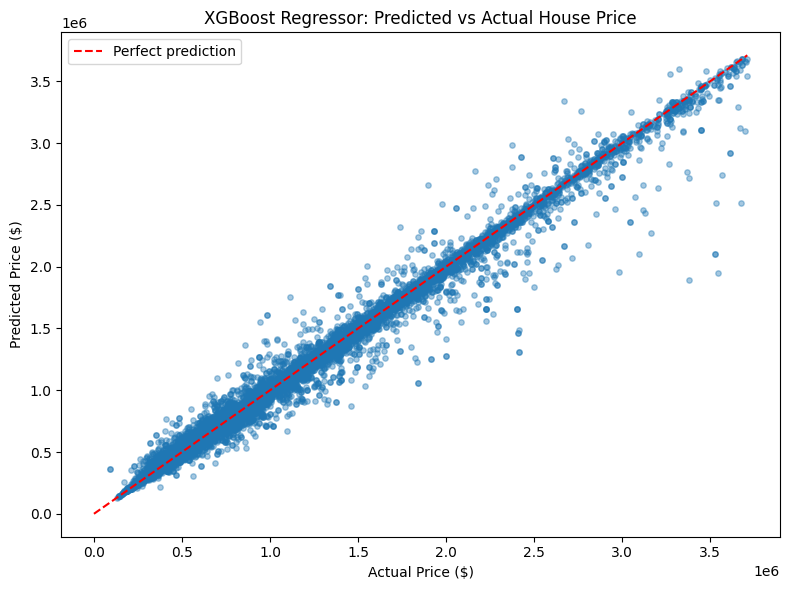

In [12]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Train XGBoost Regressor
xgb = XGBRegressor(n_estimators=200, subsample=0.7, max_depth=15, learning_rate=0.1, gamma=0, colsample_bytree=0.7, objective="reg:squarederror", random_state=42, n_jobs=5)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

# Inverse log transform to get actual prices
y_pred_xgb_actual = np.exp(y_pred_xgb)
y_test_actual = np.exp(y_test)

# Evaluate on original scale
rmse_xgb = np.sqrt(mean_squared_error(y_test_actual, y_pred_xgb_actual))
mae_xgb = mean_absolute_error(y_test_actual, y_pred_xgb_actual)
r2_xgb = r2_score(y_test_actual, y_pred_xgb_actual)

print("=" * 50)
print("XGBOOST: XGBoost Regressor on Dataset 1.csv")
print("=" * 50)
print(f"RMSE:\t${rmse_xgb:,.2f}")
print(f"MAE:\t${mae_xgb:,.2f}")
print(f"R²:\t{r2_xgb:.4f}")

print(f"\nCross-validation RMSE:\t${-cross_val_score(xgb, x, y, cv=5, scoring=neg_rmse_original_scorer).mean():,.2f}")
print(f"Cross-validation MAE:\t${-cross_val_score(xgb, x, y, cv=5, scoring=neg_mae_original_scorer).mean():,.2f}")
print(f"Cross-validation R²:\t{cross_val_score(xgb, x, y, cv=5, scoring=r2_original_scorer).mean():.4f}")

# Predicted vs Actual scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred_xgb_actual, alpha=0.4, s=15)
plt.plot([0, y_test_actual.max()], [0, y_test_actual.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('XGBoost Regressor: Predicted vs Actual House Price')
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance Plot

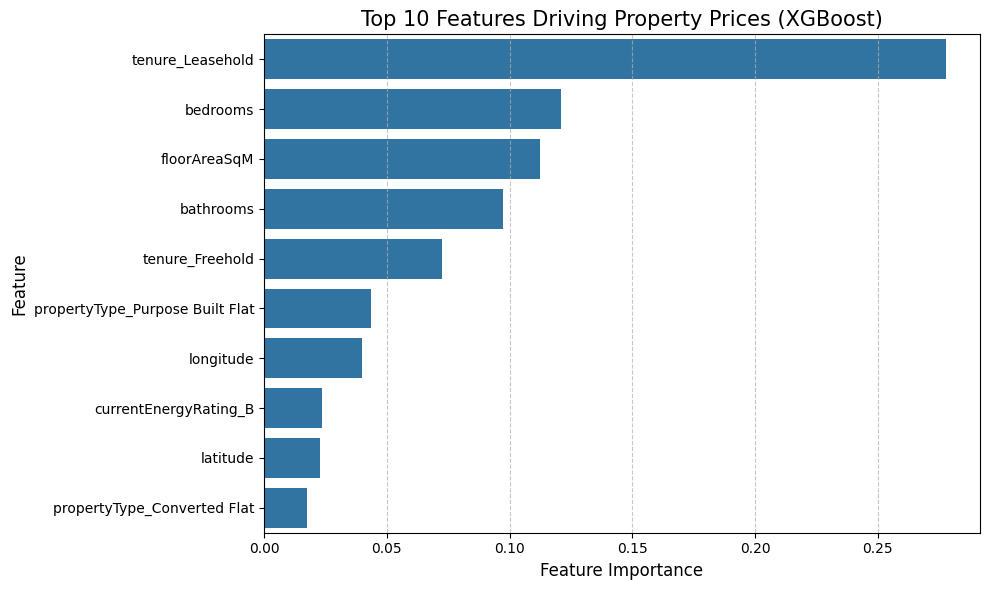

,Feature,Importance
7,tenure_Leasehold,0.277681
3,bedrooms,0.120759
4,floorAreaSqM,0.112566
2,bathrooms,0.097199
6,tenure_Freehold,0.072569
20,propertyType_Purpose Built Flat,0.043599
1,longitude,0.039870
27,currentEnergyRating_B,0.023673
0,latitude,0.022929
9,propertyType_Converted Flat,0.017572


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Fetching Feature Names and Importances from XGBoost
feature_names = x_train.columns
importances = xgb.feature_importances_

# Wrapping them together in a Pandas DataFrame for Easy Comparison and Viewing
feature_importance_xgb = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sorting Feature Importances in Descending Order
top_10_features_xgb = feature_importance_xgb.sort_values(by='Importance', ascending=False).head(10)

# Plotting Graph
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_features_xgb,
    x='Importance',
    y='Feature',
)
plt.title('Top 10 Features Driving Property Prices (XGBoost)', fontsize=15)
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
display(top_10_features_xgb[['Feature', 'Importance']])

### Supporting Evidence: Feature Importance Distribution - XGBoost vs Random Forest:

In [14]:
rf_top3 = top_10_features_rf.head(3)['Importance'].sum()
xgb_top3 = top_10_features_xgb.head(3)['Importance'].sum()

print(f"RF top-3 cumulative importance:      {rf_top3:.1%}")
print(f"XGBoost top-3 cumulative importance: {xgb_top3:.1%}")

RF top-3 cumulative importance:      94.2%
XGBoost top-3 cumulative importance: 51.1%


### Supporting Evidence: Sale Price by Tenure Type

In [15]:
# Create a copy of the data
# Reload raw data to work with actual (untransformed) prices
df_raw = pd.read_csv('kaggle_london_house_price_data.csv')
df_raw = df_raw[df_raw['saleEstimate_confidenceLevel'] == 'HIGH']
upper_quantile = df_raw['saleEstimate_currentPrice'].quantile(0.99)
df_raw = df_raw[df_raw['saleEstimate_currentPrice'] <= upper_quantile]

def to_currency(value): # Function for formatting numbers as currency
    return f"£{value:,.0f}"

# Group by tenure and get the stats
stats = df_raw.groupby('tenure')['saleEstimate_currentPrice'].describe()[['count', 'mean', '50%']]
stats.columns = ['Count', 'Mean', 'Median']

# Sort by mean
stats = stats.sort_values(by='Mean', ascending=False)

stats['Mean'] = stats['Mean'].map(to_currency)
stats['Median'] = stats['Median'].map(to_currency)

print("Mean and Median Sale Price by Tenure Type:")
print(stats)

Mean and Median Sale Price by Tenure Type:
              Count        Mean    Median
tenure                                   
Freehold   128819.0  £1,015,267  £834,000
Shared        350.0    £745,949  £660,000
Feudal       2376.0    £589,747  £515,000
Leasehold  164055.0    £574,218  £488,000


### Supporting Evidence: Mean Sale Price by Bedroom Count

In [16]:
# Reload raw data to work with actual (untransformed) prices
df_raw = pd.read_csv('kaggle_london_house_price_data.csv')
df_raw = df_raw[df_raw['saleEstimate_confidenceLevel'] == 'HIGH']
upper_quantile = df_raw['saleEstimate_currentPrice'].quantile(0.99)
df_raw = df_raw[df_raw['saleEstimate_currentPrice'] <= upper_quantile]
df_filtered = df_raw[(df_raw['bedrooms'] >= 1) & (df_raw['bedrooms'] <= 8)]

# Group and get the count and mean
bed_stats = df_filtered.groupby('bedrooms')['saleEstimate_currentPrice'].describe()[['count', 'mean']]

bed_stats.columns = ['Count', 'Mean']

bed_stats['Mean'] = [f"£{x:,.0f}" for x in bed_stats['Mean']]

print("Mean Sale Price by Bedroom Count (1-8 bedrooms):")
print(bed_stats)

Mean Sale Price by Bedroom Count (1-8 bedrooms):
             Count        Mean
bedrooms                      
1.0        44806.0    £426,910
2.0       111433.0    £596,780
3.0        77061.0    £814,800
4.0        34145.0  £1,232,186
5.0        12585.0  £1,667,798
6.0         2469.0  £2,089,648
7.0          315.0  £2,149,317
8.0           51.0  £2,059,725


### Supporting Evidence: Correlation Between floorAreaSqM, bedrooms, and bathrooms

In [17]:
# Reload raw data to work with actual (untransformed) prices
df_raw = pd.read_csv('kaggle_london_house_price_data.csv')
df_raw = df_raw[df_raw['saleEstimate_confidenceLevel'] == 'HIGH']
upper_quantile = df_raw['saleEstimate_currentPrice'].quantile(0.99)
df_raw = df_raw[df_raw['saleEstimate_currentPrice'] <= upper_quantile]
corr = df_raw[['floorAreaSqM', 'bedrooms', 'bathrooms']].dropna().corr().round(3)
print(corr.to_string())

              floorAreaSqM  bedrooms  bathrooms
floorAreaSqM         1.000     0.835      0.625
bedrooms             0.835     1.000      0.543
bathrooms            0.625     0.543      1.000


### Analysis

XGBoost improves on the Random Forest across every metric: RMSE drops from $58,734.52 to $50,734.44, MAE drops from $21,498.67 to $18,792.24, and R² improves from 0.9869 to 0.9902. Cross-validation results are close to the test results in both models, so neither model is overfitting.

While the key difference between models is the relative importance of features. In the Random Forest, floorAreaSqM was the most important feature with importance at ~0.66, followed by longitude (~0.16) and latitude (~0.12). In XGBoost, tenure_Leasehold takes the top spot at ~0.278, with floorAreaSqM dropping to third at ~0.113, and the geographic features slipping to seventh and ninth. bedrooms and bathrooms, which each had less than 3% importance in the Random Forest, now stand at ~0.12 and ~0.10 respectively.

A direct consequence of this is that importance is more evenly spread across features in XGBoost than in the Random Forest. The top three features in the Random Forest explain almost 95% of the overall importance, whereas the top three in XGBoost explain almost 51% (see code cell above).

The scatter plot for XGBoost follows the diagonal tightly across the full price range, consistent with the lower RMSE. The gap between RMSE and MAE, which reflects sensitivity to high-end outliers, narrows slightly from ~$37,000 in the Random Forest to ~$32,000 in XGBoost, meaning XGBoost handles those extreme prices marginally better.

The XGBoost scatter plot is very close to the diagonal line across the board, in line with the lowered RMSE. The difference between RMSE and MAE, which reflects sensitivity to high-end outliers, shrinks from ~$37,000 to ~$32,000 from the Random Forest to XGBoost, meaning XGBoost deals with those high prices slightly better.

tenure_Leasehold being at the top is consistent with the UK housing market. In England and Wales, leasehold property and freehold property are essentially in different price brackets. Leasehold is mainly for flat and apartments, while freehold is mainly for houses. As we see in the evidence code block below, the average price of a Freehold property is £1,207,080 whereas for a Leasehold it's £720,241, a difference of roughly £487,000. This tells us there's a large, high-value split in the data just from tenure type alone.

This is supported by the fact that tenureFreehold comes in at fifth place with a value of ~0.073. tenureLeasehold and tenure_Freehold account for about 35% of the total feature importance of the model, so just the type of tenure accounts for over a third of the XGBoost model's predictive power.

The rise of bedrooms to the second position and bathrooms to the fourth follows once tenure has separated property types. For any given tenure, the number of bedrooms is the most direct indicator of how much a property offers, and translates directly to price. The next code block below confirms a steady stepped function relationship: the mean sale price increases from £486,842 for 1-bedroom properties to £4,861,663 for 8-bedroom properties.

The transition from Random Forest to XGBoost represents a shift from a model that is strongly influenced by continuous physical size (floorAreaSqM) to one that favours legal and spatial classes (tenure, bedrooms). This would imply that while size is a key determinant of value, the utility and legality of the square footage offers a more "pure" signal to be used for gradient descent to minimize loss, particularly when penalising for outlier behaviour.

floorAreaSqM is still number three but has fallen from its position of prominence in the Random Forest. One explanation is that floor area and the number of bedrooms share information, bigger properties typically have more bedrooms and bathrooms. The last evidence code block reports a 0.835 Pearson correlation between floorAreaSqM and bedrooms, and a 0.625 Pearson correlation between floorAreaSqM and bathrooms, suggesting that once bedrooms and bathrooms have captured this signal, floorAreaSqM contributes less additional gain in the splits.

---
## Final Analysis: Dataset 1 - London House Price Prediction

### Overview

I have tested three regression algorithms - Linear Regression, Random Forest, and XGBoost - on the `kaggle_london_house_price_data.csv` dataset, restricted to the HIGH-confidence predictions for sale estimate (213,247 observations after cleaning). The target variable (saleEstimate_currentPrice) was log-transformed for modelling (to reduce right-skew), and all results are presented on the original price scale (inverse-transformed with exp).


## Model Performance Comparison

| Model | RMSE | MAE | R² | CV RMSE | CV MAE | CV R² |
|---|---|---|---|---|---|---|
| Linear Regression | £295,221 | £163,665 | 0.6694 | £301,510 | £164,073 | 0.6586 |
| Random Forest | £58,467 | £21,370 | 0.9870 | £55,515 | £21,178 | 0.9868 |
| XGBoost | £50,734 | £18,792 | 0.9902 | £47,819 | £18,788 | 0.9896 |


XGBoost is the top performer in every metric. RMSE drops by 80% and R² goes from 0.67 to 0.98 from the Linear Regression to Random Forest. XGBoost then squeezes out one more bit of performance - a 13% improvement in RMSE and 12% improvement in MAE over Random Forest. Importantly, the test and cross-validated scores of all three models are close to each other, confirming that none are overfitting.

---

### Linear Regression

Linear Regression establishes the performance baseline, which has an R² of 0.67 and a CV R² of 0.66. The RMSE of £295,221 is almost 1.8× the MAE of £163,665, which indicates that there are significant outlier errors, especially on the high end of the distribution. This is confirmed by the scatter plot: the predictions are stable for low prices, but highly volatile for high prices, with some predicted prices of over £10M for properties worth £2.5-3.5M.

The top feature is floorAreaSqM (coefficient +0.289 in log-space, i.e. a 29% increase in price per std dev). On the negative side of the coefficient plot, we see a number of property-type dummies: propertyTypePurpose Built Flat (−0.304), propertyTypeConverted Flat (−0.199), and propertyType_Flat/Maisonette (−0.192) are all massive discounts relative to the baseline (detached houses), which is common with UK market dynamics.

Two of the engineer features on the negative side of the coefficient plot are geographic: latloninteraction (−0.152) and disttocenter (−0.124). We engineered these features specifically to allow linear regression to make use of additive effects - taking the cross-product of latitude and longitude, we have a very basic attempt at capturing joint geographic pricing gradients. The negative signs suggest that properties that are distant from, or at certain cross-products of, the dataset centre tend to be less expensive. Even with this work-around, Linear Regression is unable to capture the non-linear spatial effects.

---

### Random Forest

Random Forest beats the baseline with an R² of 0.9869 and a MAE of £21,498, being 86% lower than the Linear Regression's MAE.

The feature importance chart paints a different picture about what drives house prices. floorAreaSqM is the big feature (66.4%), followed by longitude (15.8%) and latitude (12.0%) making up almost 94.2% of the top-3 cumulative importance. This compares to the Linear Regression where the coordinates were barely significant. The reason is that tree-based models are able to learn highly non-linear spatial splits, i.e. "if longitude is between X and Y AND latitude is between A and B, then the property is in a premium zone." This is confirmed by the Central London analysis: properties in central London (Westminster, City of London, Kensington & Chelsea, Camden core) are trading at a mean 1.11× premium, with a 1.15× premium at the 90th percentile.

The remaining features each contribute less than 3% to the model, not because they are not important, but because the information in them is captured by floor area and location, once these are known (a result of Random Forest's bagging strategy which puts most of the splitting power to the most globally discriminative continuous features).

---

### XGBoost

XGBoost achieves the best results: R² of 0.990, MAE of £18,792, RMSE of £50,734. The gap between RMSE and MAE decreases from ~£37,236 (Random Forest) to ~£31,942 (XGBoost), implying that XGBoost handles the most extreme valuations slightly better.

The big deal is the complete reshuffling of feature importances. tenure_Leasehold rockets to the top (27.8%) bumping floorAreaSqM down (now 11.3%). bedrooms moves up to second (12.1%) and bathrooms to fourth (9.8%). XGBoost's top-3 feature importances account for only 51.1% of the overall importance (compared to 89.5% for Random Forest), suggesting a more distributed model that is less reliant on any single feature.

The importance of tenure is confirmed in the data: mean price for Freehold is £1,015,267 vs. £574,218 for Leasehold - a £441,049 difference largely due to the house-vs-flat split in the UK property market. The features tenureLeasehold and tenureFreehold together account for 35% of XGBoost importance. After tenure splits on the property type, the next most direct signal is bedrooms: average price increases consistently from £426,910 (1 bedroom) to £2,059,725 (8 bedrooms).

floorAreaSqM drops in importance because it is strongly correlated to the counts of rooms (its Pearson correlation is 0.835 with bedrooms, and 0.625 with bathrooms). After XGBoost has split on bedrooms and bathrooms, it receives less information gain from splits on floor area.

---

### Key points

Non-linearity is essential. Linear Regression cannot model the non-linearities in the effects of space and interactions with property type, and thus has an R² of 0.67 compared with 0.99 for both trees. Spatial and property-type interactions are non-linear and need to be modelled by tree-based approaches.

Feature importance is model-dependent. The most important variable to price changes from floorAreaSqM (Random Forest) to tenure_Leasehold (XGBoost), not because of a change in data, but because XGBoost, with its boosted residual-fitting approach, draws out legal and categorical splits that Random Forest, with its bagging approach, under-weights in favour of the most globally discriminative continuous attributes.

XGBoost is the recommended model. It has the lowest error on both test and cross-validation, spreads out the features more uniformly and performs slightly better on high price outliers than Random Forest. It has a similar cross-validated (CV R² 0.9896) and test (R² 0.9902) performance, which suggests that it generalizes well.